In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("insurance.csv")


In [175]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [176]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [178]:
df.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [199]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"]=le.fit_transform(df["smoker"])
df["region"]=le.fit_transform(df["region"])

> sex : 0=female, 1=male .

>smoker: 0=No, 1=Yes.

>region : 0=northeast, 1=northwest, 2=southeast, 3=southwest .

# EDA

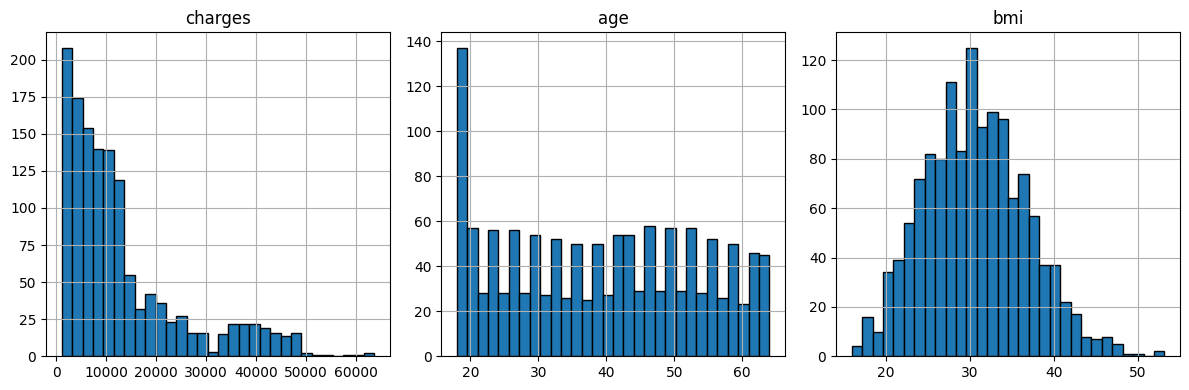

In [182]:
df[["charges", "age", "bmi"]].hist(
    bins=30,
    figsize=(12, 4),
    layout=(1, 3),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

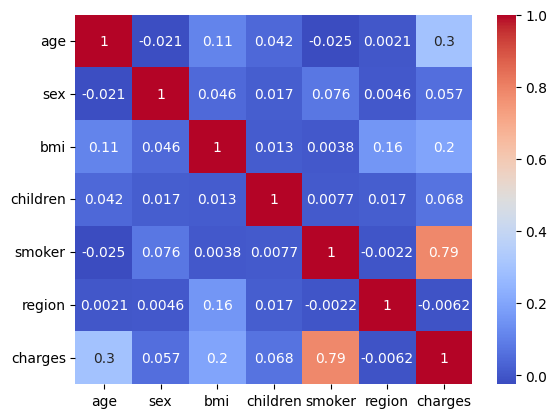

In [183]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm");


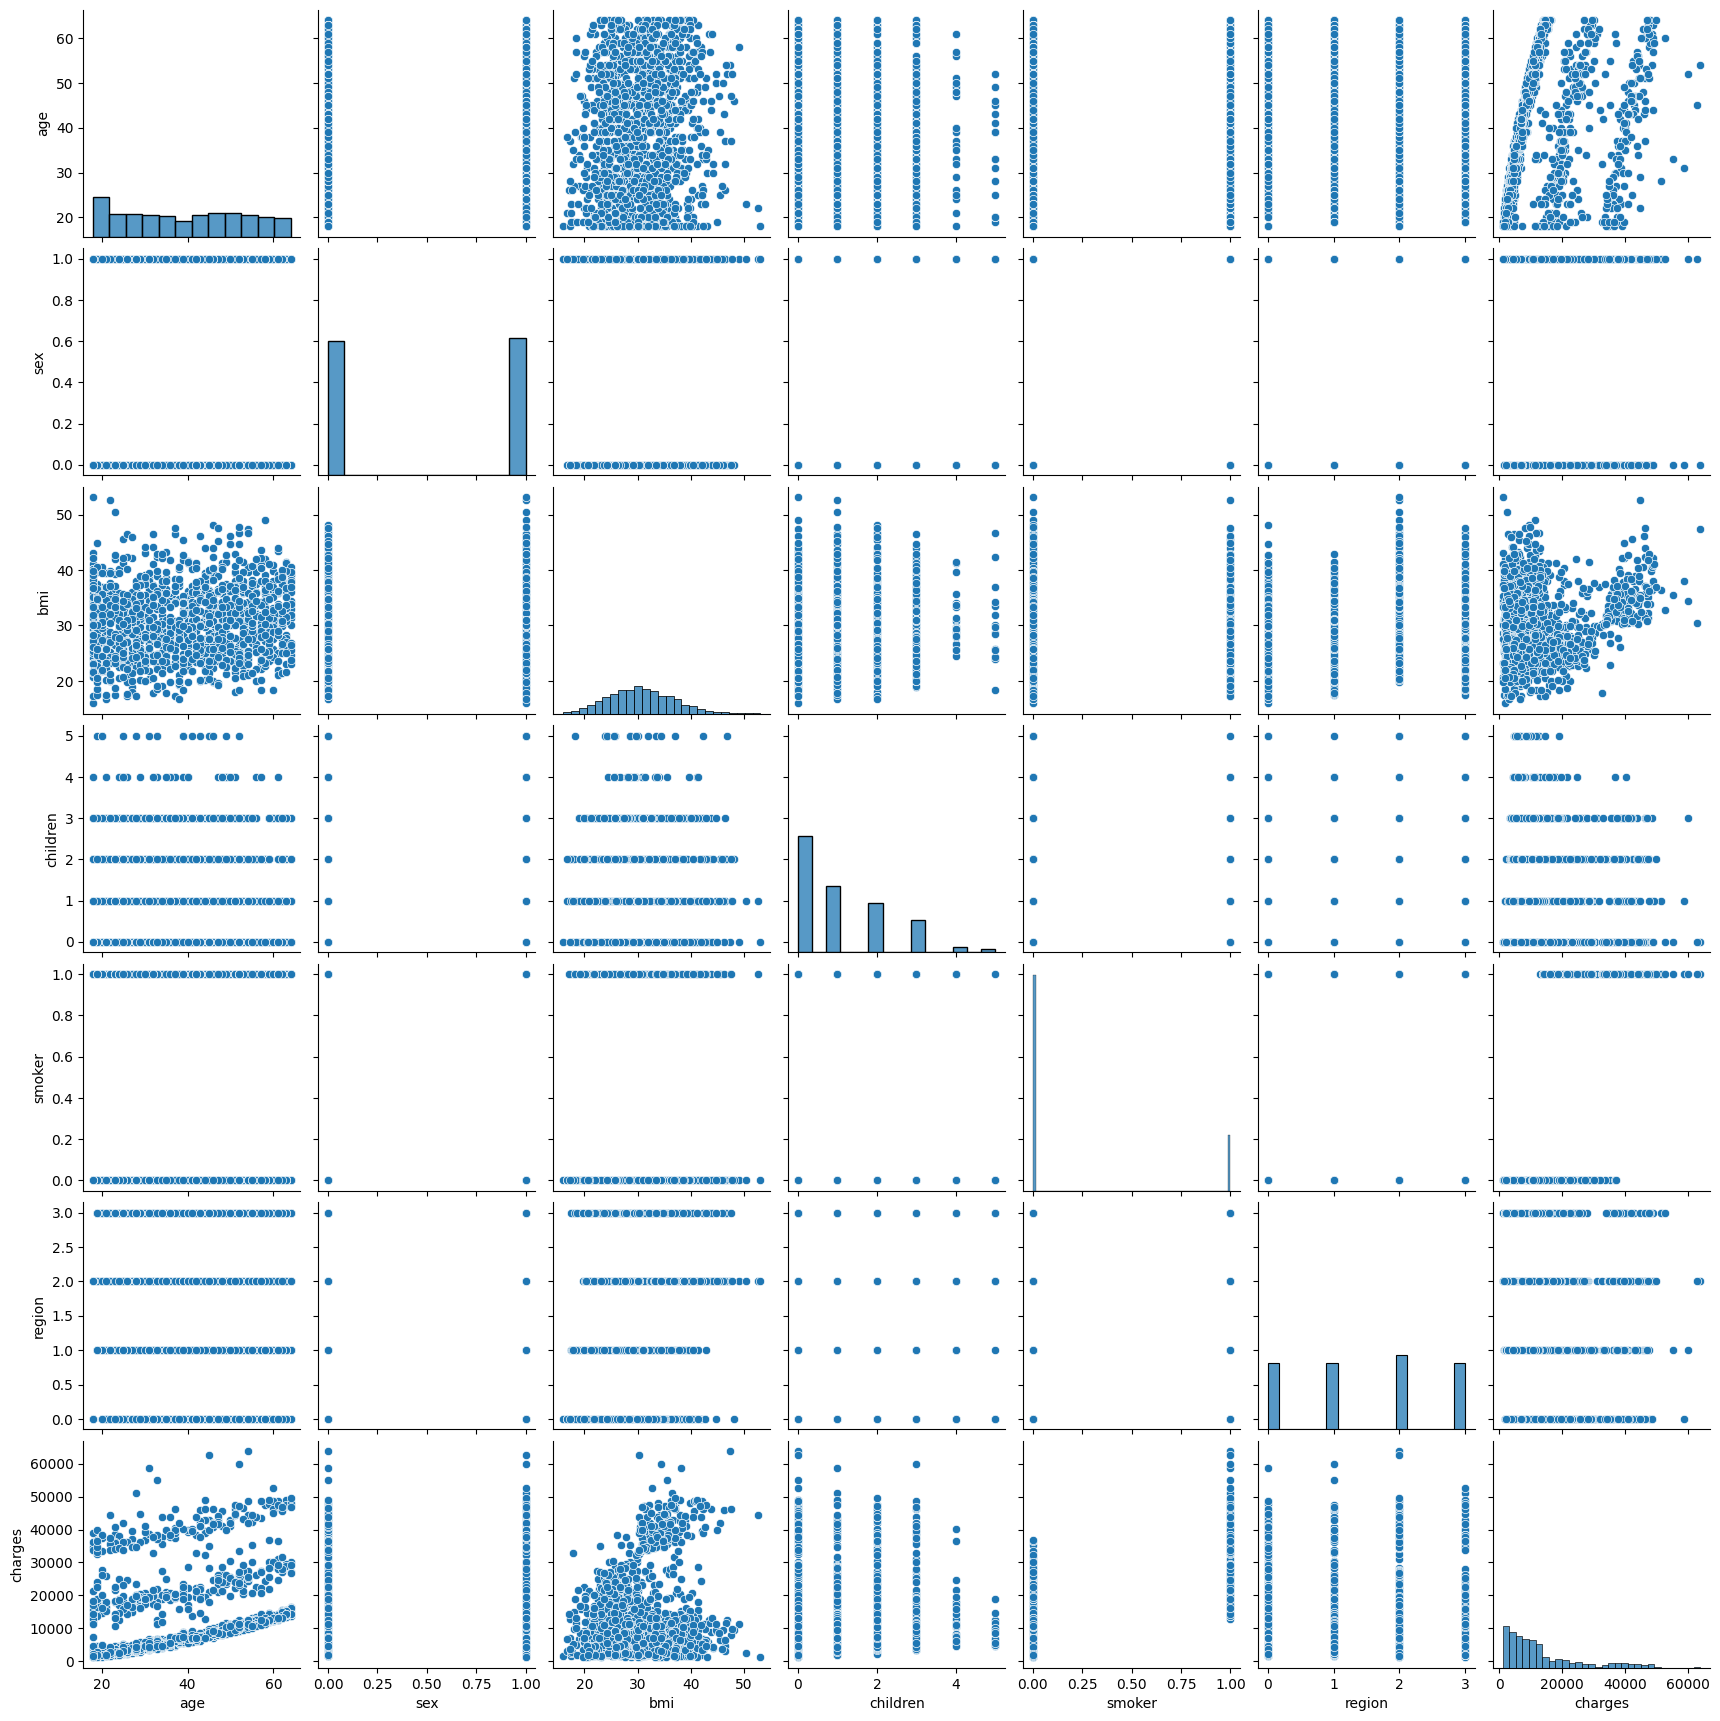

In [184]:
sns.pairplot(df);


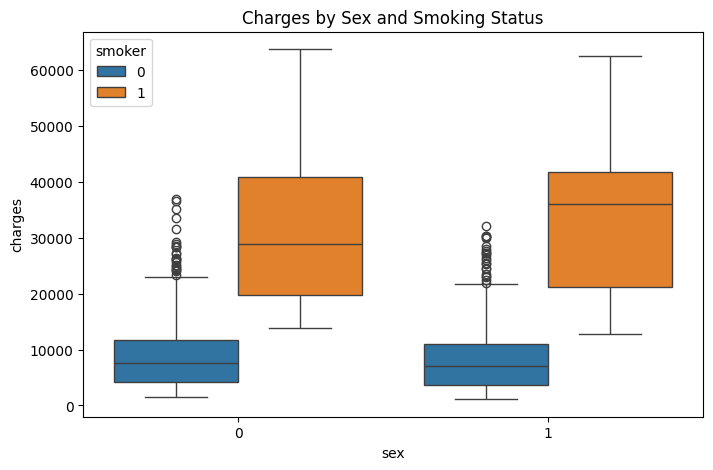

In [185]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sex",
    y="charges",
    hue="smoker"
)
plt.title("Charges by Sex and Smoking Status")
plt.show()

The box plot shows that the smokers' charges are generally higher than those of non-smokers.

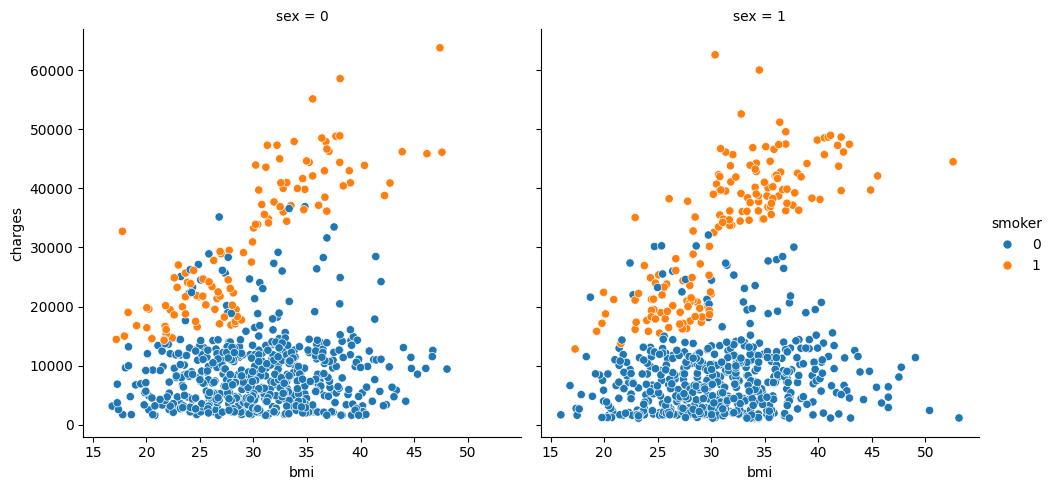

In [186]:
sns.relplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",   
    col="sex",      
    height=5,
    aspect=1
)

plt.show()

Among non-smokers, the relationship between BMI, age, and charges remains within a relatively expected range. However, smokers consistently have substantially higher charges across all BMI and age groups.

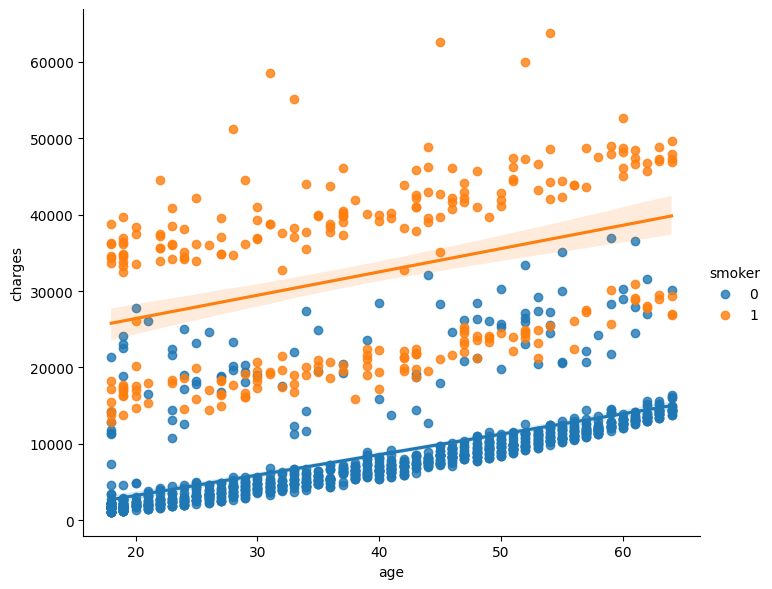

In [187]:
sns.lmplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    height=6,
    aspect=1.2
);

Earlier, we noticed that most individuals were under the age of 20. Let's take a closer look at this group and see if anything interesting stands out.

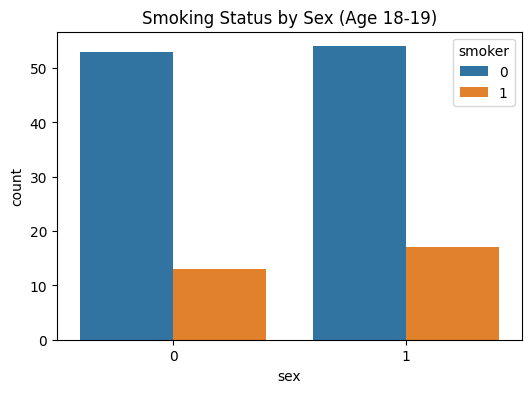

In [188]:
teenage=df[(df["age"]==18)|(df["age"]==19)]

plt.figure(figsize=(6,4))

sns.countplot(
    data=teenage,
    x="sex",
    hue="smoker"
)
plt.title("Smoking Status by Sex (Age 18-19)")
plt.show()

There doesn't seem to be anything new or unexpected here. Most individuals under the age of 20 are non-smokers, regardless of gender.


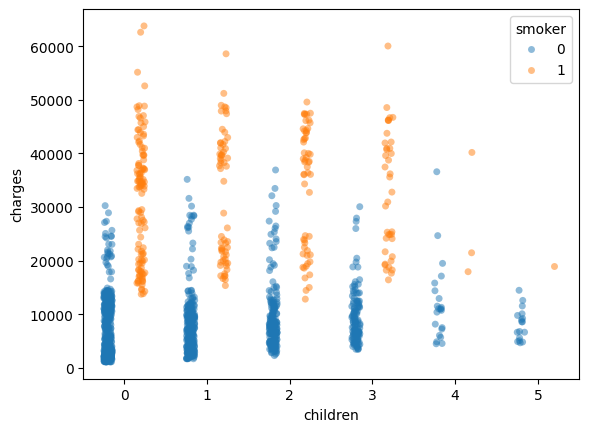

In [189]:
sns.stripplot(
    data=df,
    x="children",
    y="charges",
    hue="smoker",
    dodge=True,
    alpha=0.5
);

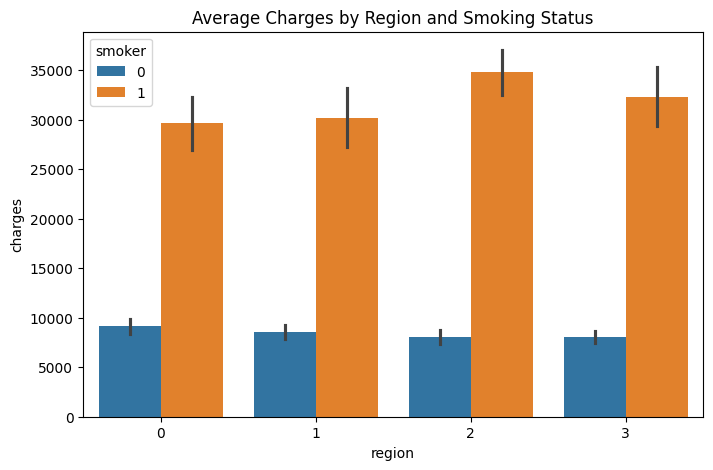

In [190]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="region",
    y="charges",
    hue="smoker"
)

plt.title("Average Charges by Region and Smoking Status")
plt.show()

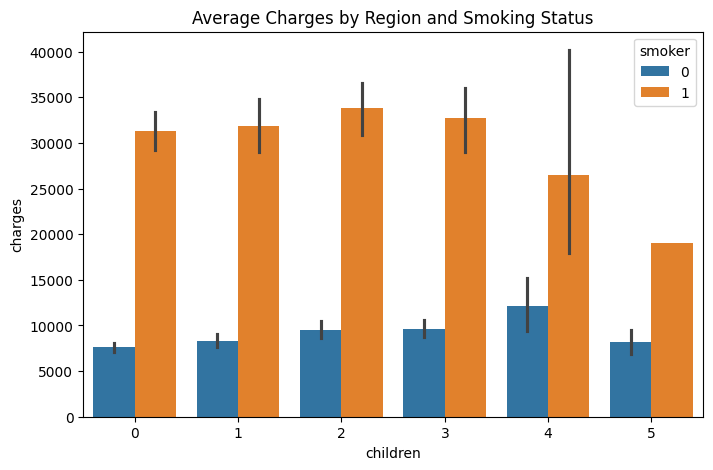

In [191]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="children",
    y="charges",
    hue="smoker"
)

plt.title("Average Charges by Region and Smoking Status")
plt.show()

In [192]:
x=df.drop(columns="charges")
y=df["charges"]

from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

from sklearn.linear_model import LinearRegression
lm=LinearRegression()

In [193]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

lm_poly.fit(x_train_poly, y_train)

y_pred_poly = lm_poly.predict(x_test_poly)

In [206]:
lm.fit(x_train,y_train)
y_pred=lm.predict(x_test)

print("Linear Regression Model Predictions:")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R²:", metrics.r2_score(y_test, y_pred))

Linear Regression Model Predictions:
MAE: 4155.239843059382
RMSE: 5814.246890069996
R²: 0.7694415927057692


In [205]:
print("Polynomial Regression Model Predictions:")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_poly))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_poly)))
print("R²:", metrics.r2_score(y_test, y_pred_poly))

Polynomial Regression Model Predictions:
MAE: 2677.9002136483828
RMSE: 4469.533082721667
R²: 0.8637557014627605
